# 📊 Talep & Stok Analizi
### Kapsamlı Veri Analizi ve İstatistiksel Çalışma

---

Perakende **talep tahmini ve stok optimizasyonu** için uçtan uca analiz. Veri
tanıtımından hipotez testlerine ve modellemeye kadar her adım, altında **bulgu +
iş anlamı** yorumuyla sunulur.

| | |
|---|---|
| **Veri** | 76.000 satır · 5 mağaza × 20 ürün × 760 gün |
| **Hedef** | Günlük talep (`Demand`) |
| **Yöntem** | EDA · Hipotez testleri (α = 0.05) · Baseline modelleme |
| **Araçlar** | pandas · seaborn/matplotlib · scipy · statsmodels · scikit-learn |

---

### İçindekiler
1. Veri Tanıtımı 2. Temizlik 3. Keşifsel Analiz (EDA)
4. Hipotez Testleri 5. Modelleme 6. Sonuç

## 0 · Kurulum ve profesyonel görsel tema

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

%matplotlib inline

# --- Design system (validated palette) ---------------------------------------
BLUE, INK, INK2, GRID, SURF = "#2a78d6", "#0b0b0b", "#52514e", "#e7e7e3", "#ffffff"
CAT = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
STATUS = {"good": "#0ca30c", "warning": "#fab219", "critical": "#d03b3b"}
DIVERGING = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#d03b3b"])
SEQ = "Blues"

mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "figure.dpi": 120, "savefig.dpi": 120, "savefig.bbox": "tight",
    "axes.titlesize": 13.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.titlepad": 12,
    "axes.labelsize": 11, "axes.labelcolor": INK2,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.9,
    "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "text.color": INK, "font.size": 10.5, "legend.frameon": False, "legend.fontsize": 10,
})
sns.set_palette(CAT)

df = pd.read_csv("../data/demand_forecasting.csv")
df["Date"] = pd.to_datetime(df["Date"])
print("Yüklendi:", df.shape)
df.head()

Yüklendi: (76000, 16)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


*Tüm grafikler tek bir doğrulanmış renk sistemi kullanır: kategorik kimlik için sabit sıralı paleti, büyüklük için tek-hue mavi, kutupluluk (korelasyon) için mavi↔gri↔kırmızı diverging. Izgara geri planda, başlıklar sola hizalı.*

## 1 · Veri Tanıtımı

Günlük **mağaza × ürün** talebi ve onu etkileyen faktörler: fiyat, indirim,
promosyon, hava durumu, mevsim, rakip fiyatı, salgın, envanter.

In [2]:
print("Tarih aralığı :", df["Date"].min().date(), "→", df["Date"].max().date())
print("Mağaza / Ürün / Gün:", df["Store ID"].nunique(), "/",
      df["Product ID"].nunique(), "/", df["Date"].nunique())
df.dtypes.to_frame("tip")

Tarih aralığı : 2022-01-01 → 2024-01-30
Mağaza / Ürün / Gün: 5 / 20 / 760


,tip
Date,datetime64[us]
Store ID,str
Product ID,str
Category,str
Region,str
Inventory Level,int64
Units Sold,int64
Units Ordered,int64
Price,float64
Discount,int64


In [3]:
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
Date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Inventory Level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
Promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
Competitor Pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
Epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
Demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


> **Bulgu.** 5 mağaza × 20 ürün × 760 gün = dengeli bir panel (76.000 satır).
> Hedef `Demand` geniş bir yayılıma sahip.
>
> **İş anlamı.** Panel yapısı hem kesitsel (mağaza/ürün) hem zamansal (mevsim/trend)
> analize ve zaman-serisi modellemesine uygundur.

## 2 · Veri Temizliği

In [4]:
checks = pd.DataFrame({
    "eksik_deger": df.isnull().sum(),
}).query("eksik_deger > 0")
print("Yinelenen satir :", df.duplicated().sum())
print("Negatif talep   :", int((df["Demand"] < 0).sum()))
print("Negatif fiyat   :", int((df["Price"] < 0).sum()))
print("Eksik deger     :", "YOK" if checks.empty else checks.to_string())

Yinelenen satir : 0
Negatif talep   : 0
Negatif fiyat   : 0
Eksik deger     : YOK


> **Bulgu.** Veri temiz — eksik değer, yinelenen satır ve negatif değer **yok**.
> `Date` datetime'a çevrildi.
>
> **İş anlamı.** Temizlik ihtiyacı minimum; bulgulara güven yüksek.

## 3 · Keşifsel Veri Analizi (EDA)

### 3.1 · Kategoriye göre talep dağılımı

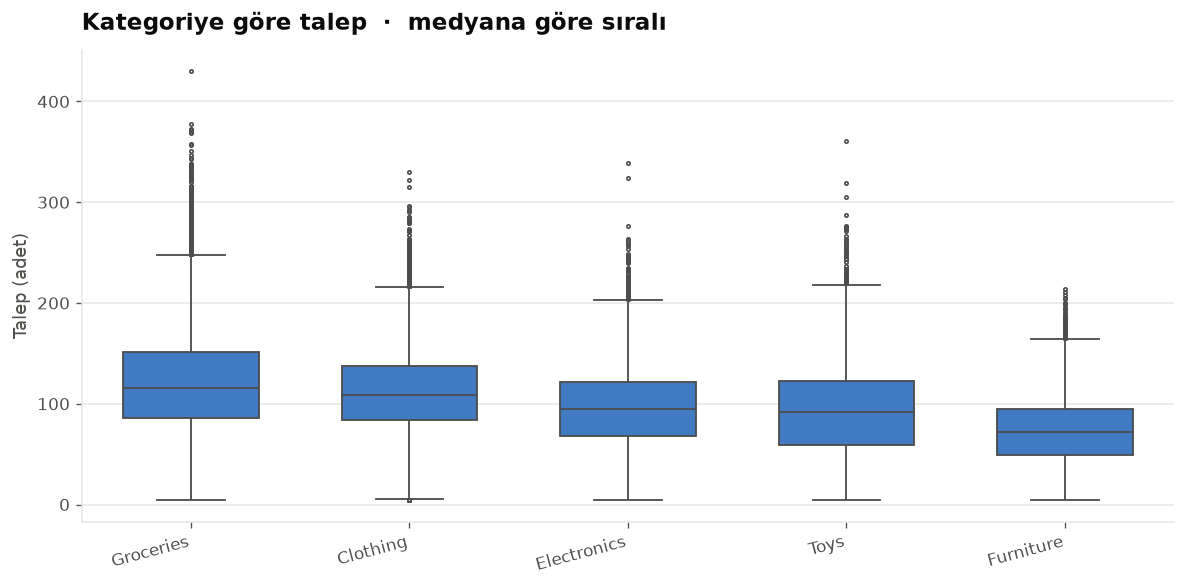

In [5]:
order = df.groupby("Category")["Demand"].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="Category", y="Demand", order=order, color=BLUE,
            width=0.62, fliersize=2, linewidth=1.1, ax=ax)
ax.set_title("Kategoriye göre talep  ·  medyana göre sıralı")
ax.set_xlabel(""); ax.set_ylabel("Talep (adet)")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
plt.tight_layout(); plt.show()

> **Bulgu.** Medyan talep ve yayılım kategoriye göre değişiyor; bazı kategoriler
> daha yüksek ve daha oynak.
>
> **İş anlamı.** Güvenlik stoğu kategoriye göre ayarlanmalı — oynak kategoriler daha
> fazla tampon ister.

### 3.2 · Mevsime göre talep dağılımı

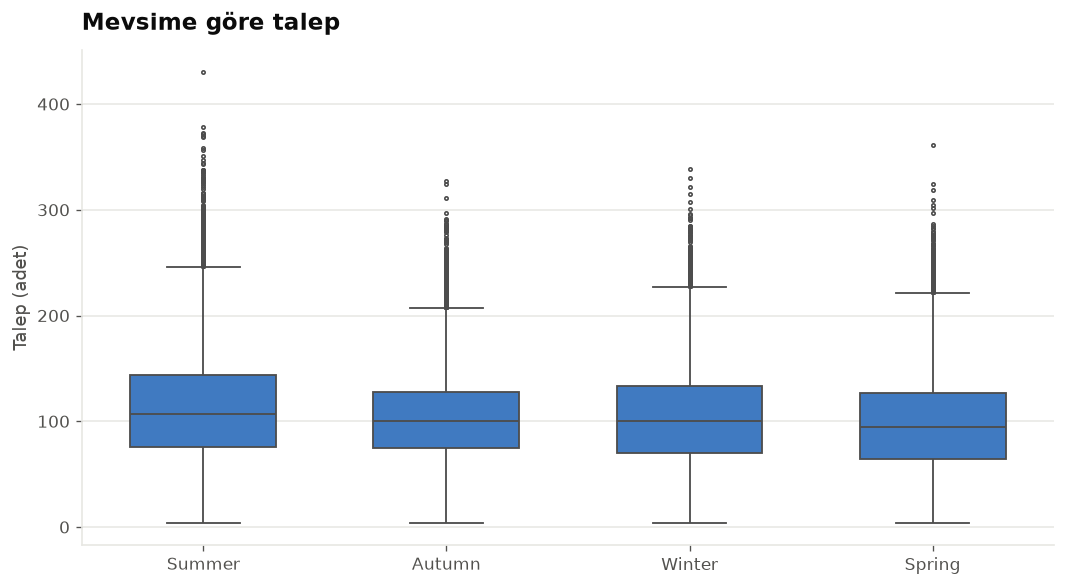

In [6]:
order = df.groupby("Seasonality")["Demand"].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="Seasonality", y="Demand", order=order, color=BLUE,
            width=0.6, fliersize=2, linewidth=1.1, ax=ax)
ax.set_title("Mevsime göre talep"); ax.set_xlabel(""); ax.set_ylabel("Talep (adet)")
plt.tight_layout(); plt.show()

> **Bulgu.** Mevsimler arası talep seviyesinde gözle görülür fark (mevsimsellik).
>
> **İş anlamı.** Sezon öncesi stok planı kritik; yüksek sezona hazırlık stok-out
> riskini düşürür.

### 3.3 · Mağazaya göre talep dağılımı

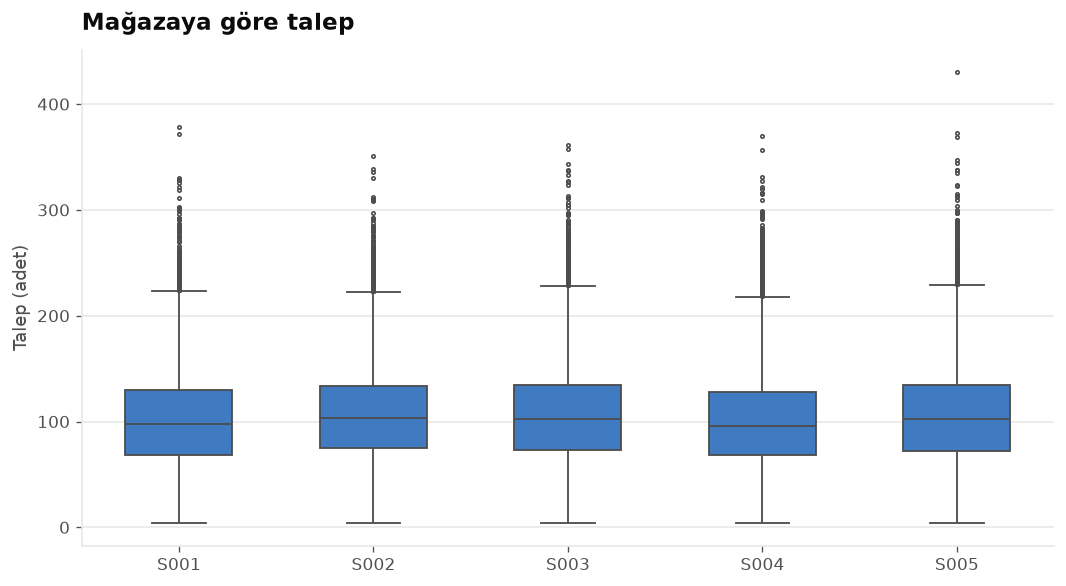

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="Store ID", y="Demand", color=BLUE,
            width=0.55, fliersize=2, linewidth=1.1, ax=ax)
ax.set_title("Mağazaya göre talep"); ax.set_xlabel(""); ax.set_ylabel("Talep (adet)")
plt.tight_layout(); plt.show()

> **Bulgu.** Mağazalar arası dağılım benzer, medyanlar hafif farklı.
>
> **İş anlamı.** Küçük farklar dağıtım (allocation) kararlarında dikkate alınmalı.

### 3.4 · Sayısal değişkenler arası korelasyon

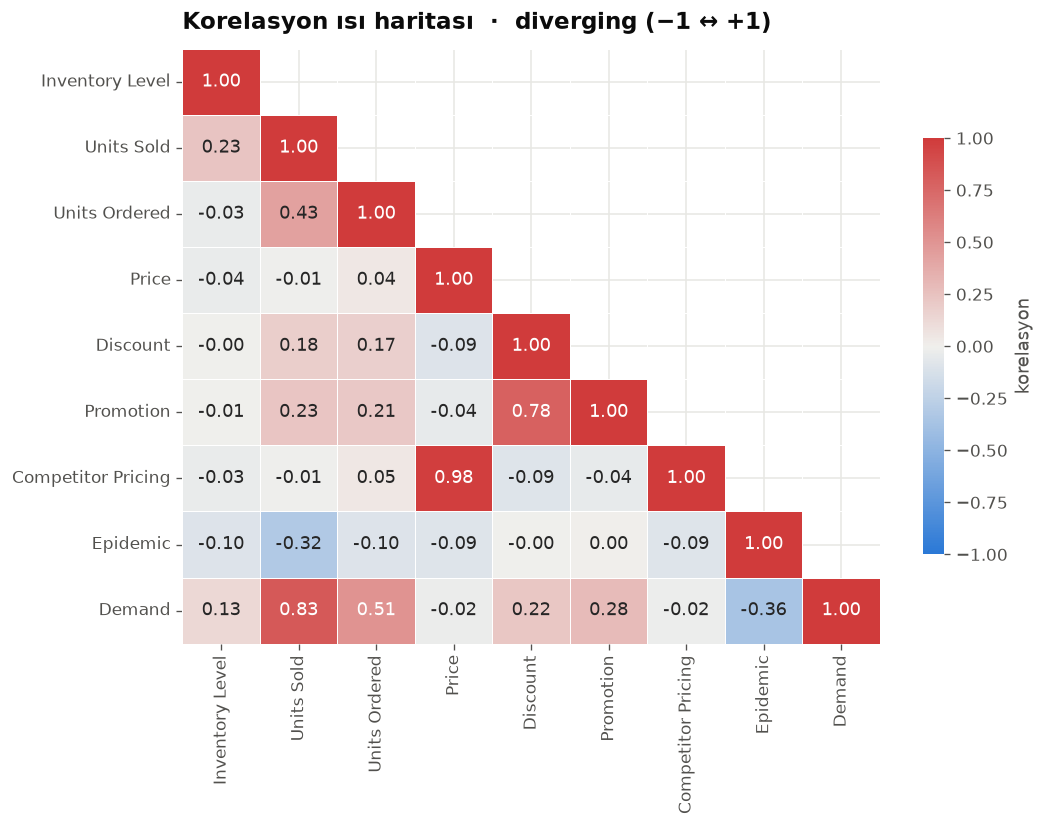

In [8]:
num = df.select_dtypes(include="number")
corr = num.corr()
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=DIVERGING, center=0,
            vmin=-1, vmax=1, linewidths=0.6, linecolor=SURF,
            cbar_kws={"shrink": 0.7, "label": "korelasyon"}, ax=ax)
ax.set_title("Korelasyon ısı haritası  ·  diverging (−1 ↔ +1)")
plt.tight_layout(); plt.show()

> **Bulgu.** `Demand` ile en güçlü ilişki sonuç değişkenlerinde (`Units Sold/Ordered`
> — modelde **sızıntı**, kullanılmaz). `Price` ve `Discount` daha zayıf ama anlamlı.
>
> **İş anlamı.** Fiyat ve indirim talebin yönlendirilebilir kaldıraçları; sonuç
> değişkenleri modele sokulmamalı.

### 3.5 · Hava durumuna göre talep — violin

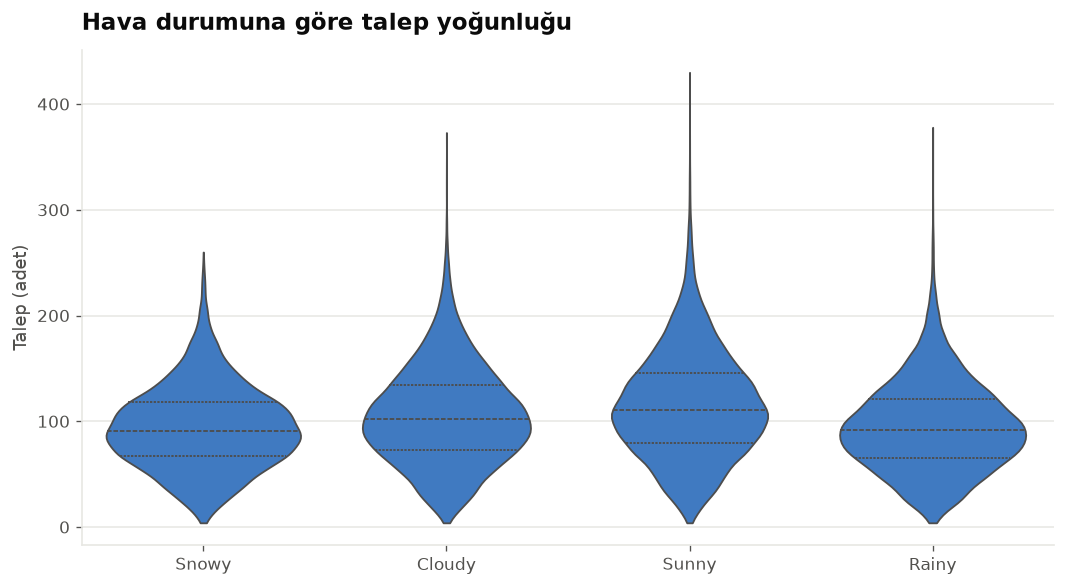

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=df, x="Weather Condition", y="Demand", color=BLUE,
               inner="quartile", linewidth=1.1, cut=0, ax=ax)
ax.set_title("Hava durumuna göre talep yoğunluğu"); ax.set_xlabel(""); ax.set_ylabel("Talep (adet)")
plt.tight_layout(); plt.show()

> **Bulgu.** Dağılım biçimi hava koşuluna göre değişiyor.
>
> **İş anlamı.** Hava tahmini kısa vadeli talep planlamasına katkı sağlar.

### 3.6 · Fiyat – Talep ilişkisi — regresyonlu scatter

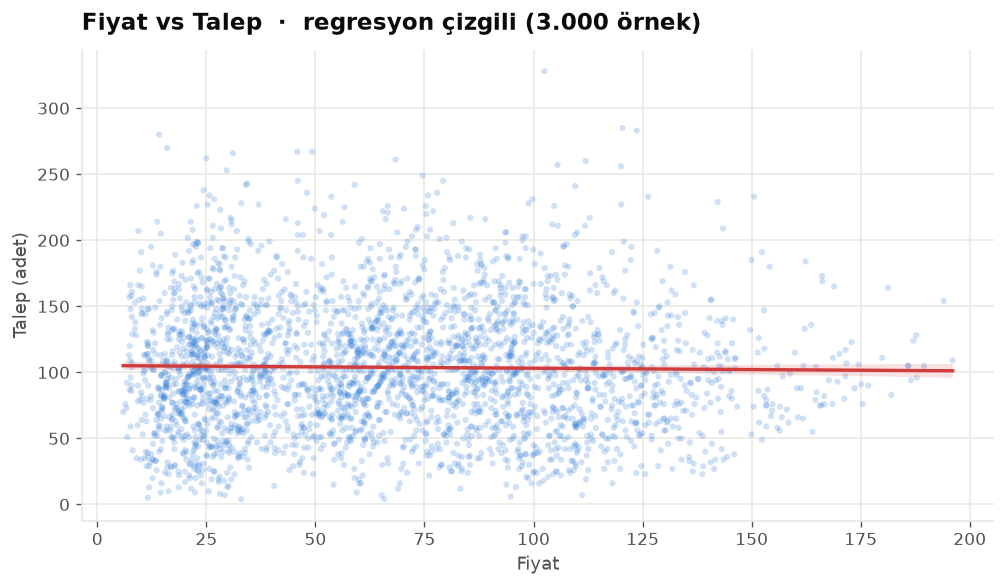

In [10]:
samp = df.sample(3000, random_state=42)
fig, ax = plt.subplots(figsize=(8.5, 5))
sns.regplot(data=samp, x="Price", y="Demand", ax=ax,
            scatter_kws={"alpha": 0.22, "s": 14, "color": BLUE, "edgecolor": "none"},
            line_kws={"color": STATUS["critical"], "linewidth": 2})
ax.set_title("Fiyat vs Talep  ·  regresyon çizgili (3.000 örnek)")
ax.set_xlabel("Fiyat"); ax.set_ylabel("Talep (adet)")
plt.tight_layout(); plt.show()

> **Bulgu.** Regresyon çizgisi hafif **negatif eğimli** — fiyat arttıkça talep
> düşme eğiliminde (talep esnekliği).
>
> **İş anlamı.** Fiyat/indirim talebi yönetmenin doğrudan kaldıracı.

### 3.7 · Günlük toplam talep — zaman serisi

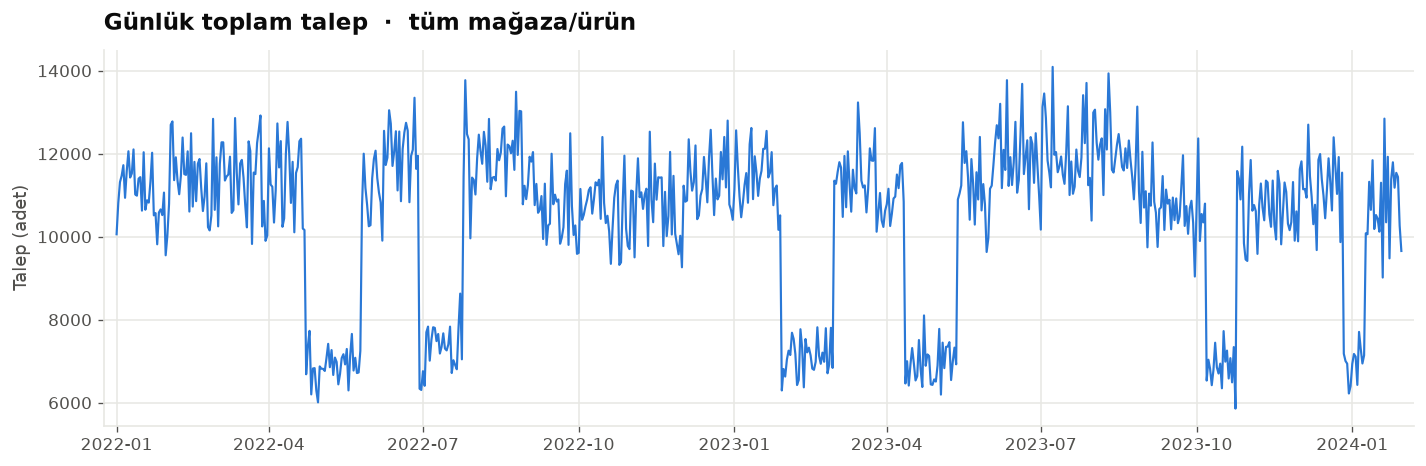

In [11]:
daily = df.groupby("Date")["Demand"].sum().asfreq("D")
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily.index, daily.values, color=BLUE, linewidth=1.3)
ax.set_title("Günlük toplam talep  ·  tüm mağaza/ürün")
ax.set_xlabel(""); ax.set_ylabel("Talep (adet)")
ax.margins(x=0.01); plt.tight_layout(); plt.show()

> **Bulgu.** Dalgalanma ve olası mevsimsel örüntü; belirgin kopukluk yok.
>
> **İş anlamı.** Zaman-serisi modellemesi (lag/rolling) anlamlı — geçmiş talep güçlü
> bir yordayıcı.

### 3.8 · Zaman serisi ayrıştırma (trend / mevsim / artık)

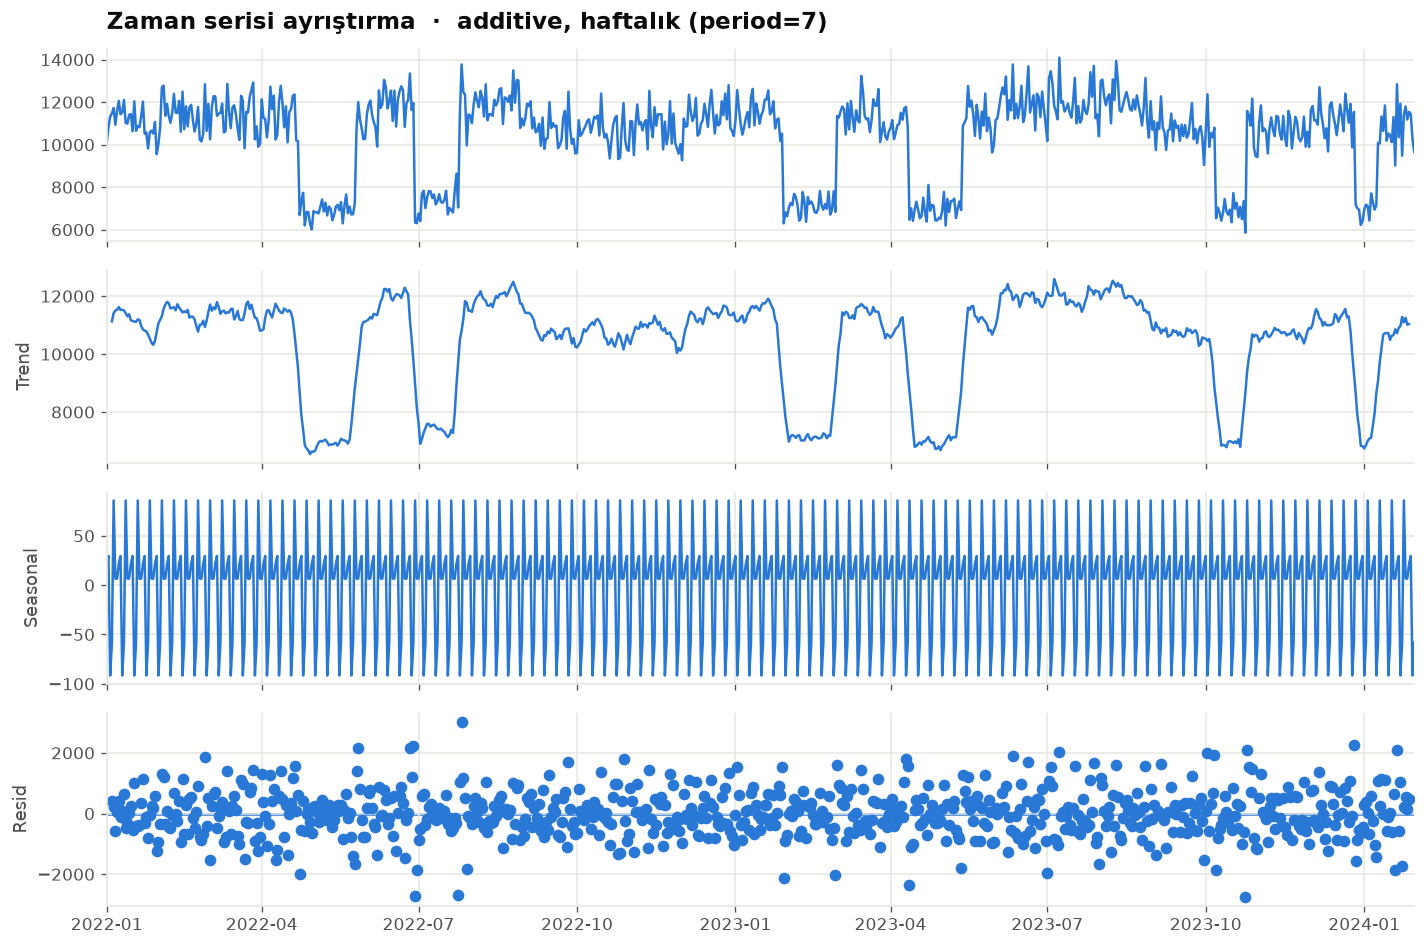

In [12]:
res = seasonal_decompose(daily, model="additive", period=7)
fig = res.plot(); fig.set_size_inches(12, 8)
for a in fig.axes:
    a.set_facecolor(SURF)
    for ln in a.get_lines(): ln.set_color(BLUE)
fig.axes[0].set_title("Zaman serisi ayrıştırma  ·  additive, haftalık (period=7)",
                      loc="left", fontweight="bold")
plt.tight_layout(); plt.show()

> **Bulgu.** Belirgin **trend**, **haftalık mevsimsel** bileşen ve göreli küçük
> **artık**.
>
> **İş anlamı.** Haftalık örüntü planlamada kullanılmalı; trend orta vadeli
> kapasite/tedarik kararlarını bilgilendirir.

### 3.9 · Hareketli ortalamalar (7 & 30 gün)

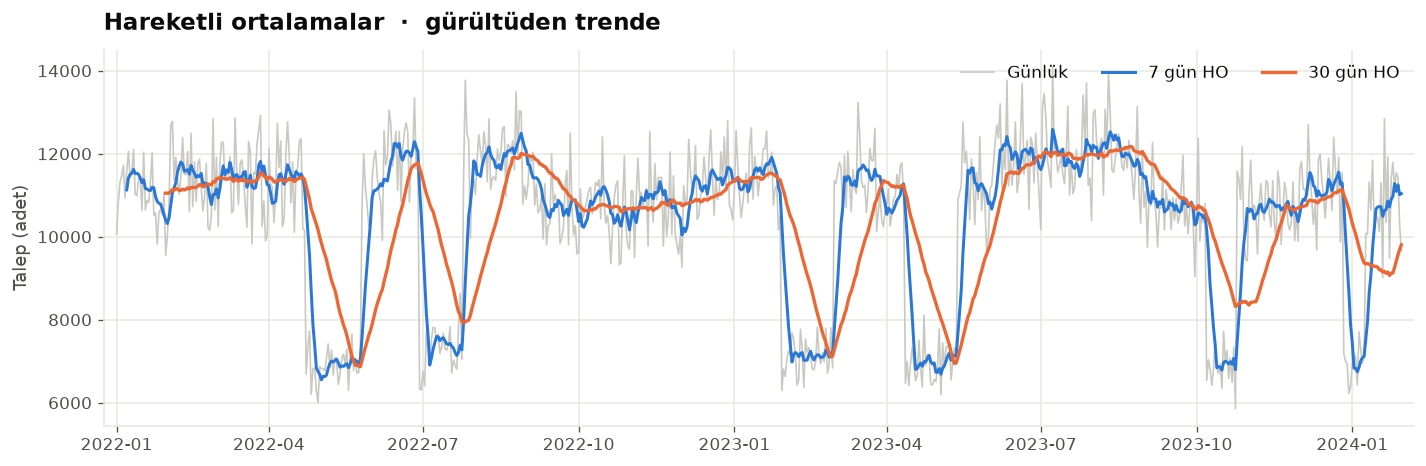

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily.index, daily.values, color="#c9c9c2", linewidth=1, label="Günlük")
ax.plot(daily.index, daily.rolling(7).mean(), color=CAT[0], linewidth=1.8, label="7 gün HO")
ax.plot(daily.index, daily.rolling(30).mean(), color=CAT[7], linewidth=2, label="30 gün HO")
ax.set_title("Hareketli ortalamalar  ·  gürültüden trende")
ax.set_xlabel(""); ax.set_ylabel("Talep (adet)"); ax.margins(x=0.01)
ax.legend(loc="upper right", ncol=3); plt.tight_layout(); plt.show()

> **Bulgu.** 7 ve 30 günlük ortalamalar gürültüyü yumuşatıp seviye/trendi
> belirginleştiriyor.
>
> **İş anlamı.** Kısa (7g) ortalama operasyonel yeniden sipariş, uzun (30g) taktiksel
> plan için sinyal.

### 3.10 · Otokorelasyon — ACF / PACF

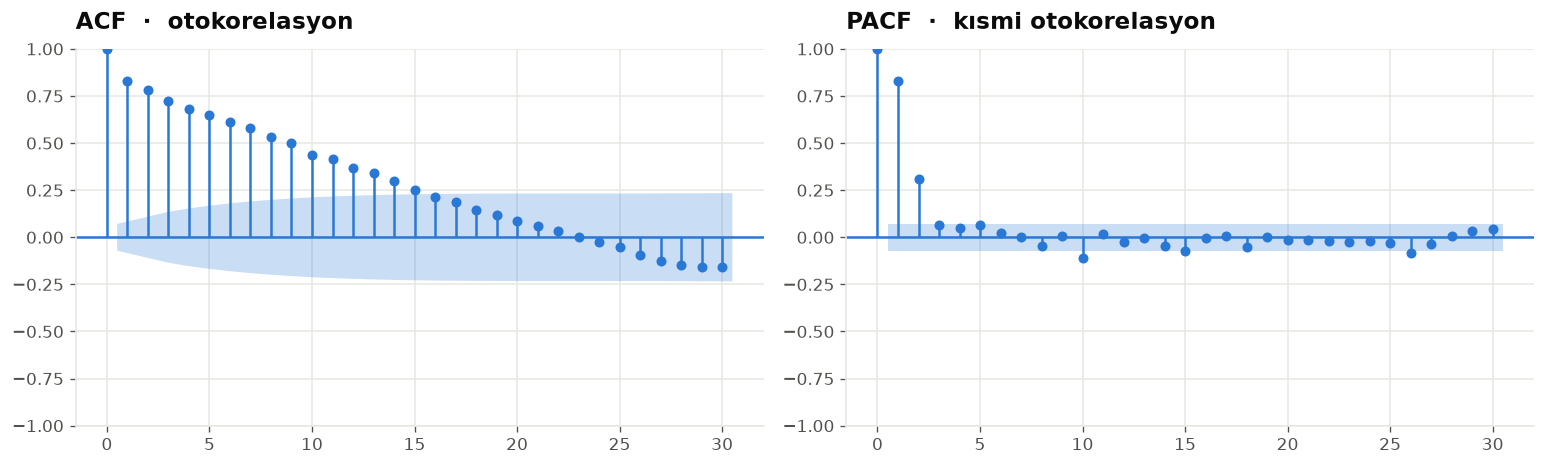

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(daily, lags=30, ax=ax[0], color=BLUE, vlines_kwargs={"colors": BLUE})
plot_pacf(daily, lags=30, ax=ax[1], method="ywm", color=BLUE, vlines_kwargs={"colors": BLUE})
ax[0].set_title("ACF  ·  otokorelasyon"); ax[1].set_title("PACF  ·  kısmi otokorelasyon")
for a in ax: a.set_facecolor(SURF)
plt.tight_layout(); plt.show()

> **Bulgu.** ~7 gün periyodunda tekrar eden anlamlı otokorelasyon (haftalık örüntü);
> PACF ilk birkaç gecikmede belirgin.
>
> **İş anlamı.** `lag_1`, `lag_7` özellikleri modeli güçlendirir — ana pipeline'da bu
> özellikler R²'yi ~0.95'e taşıyor.

### 3.11 · Talebin normalliği — QQ plot

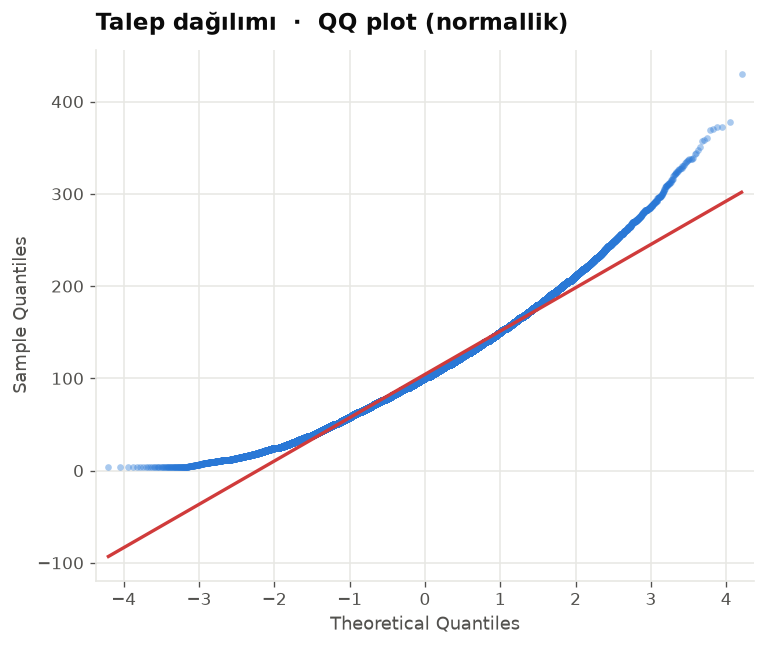

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sm.qqplot(df["Demand"], line="s", ax=ax,
          markerfacecolor=BLUE, markeredgecolor="none", alpha=0.4, markersize=4)
ax.get_lines()[1].set_color(STATUS["critical"]); ax.get_lines()[1].set_linewidth(2)
ax.set_title("Talep dağılımı  ·  QQ plot (normallik)")
plt.tight_layout(); plt.show()

> **Bulgu.** Uçlarda referans çizgisinden sapma → talep tam normal değil, kuyruklu.
>
> **İş anlamı.** Normallik varsayan yöntemler dikkatle; güvenlik stoğunda
> dağılım-serbest (quantile) yaklaşımlar değerli.

## 4 · Hipotez Testleri

Anlamlılık düzeyi **α = 0.05**. Her testte hipotez, istatistik ve **p-değeri** ile
yorum verilir.

### 4.1 · Promosyonun talebe etkisi — t-testi & Mann–Whitney U
H₀: promosyonlu ve promosyonsuz günlerde ortalama talep aynıdır.

Ortalama — promosyon: 123.3  |  promosyonsuz: 95.0
t-testi        : t=74.34,  p=0.00e+00
Mann-Whitney U : U=842214472, p=0.00e+00
Sonuç: H0 RED — fark anlamlı ✅


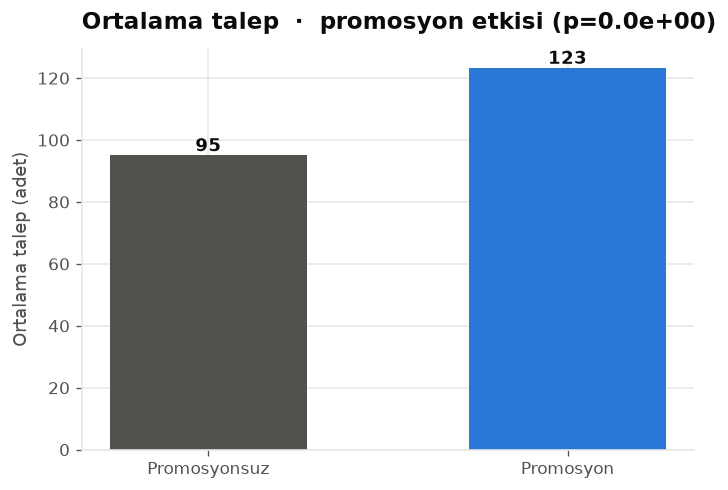

In [16]:
promo = df[df["Promotion"] == 1]["Demand"]
nopromo = df[df["Promotion"] == 0]["Demand"]
t, p_t = stats.ttest_ind(promo, nopromo, equal_var=False)
u, p_u = stats.mannwhitneyu(promo, nopromo, alternative="two-sided")
print(f"Ortalama — promosyon: {promo.mean():.1f}  |  promosyonsuz: {nopromo.mean():.1f}")
print(f"t-testi        : t={t:.2f},  p={p_t:.2e}")
print(f"Mann-Whitney U : U={u:.0f}, p={p_u:.2e}")
print("Sonuç:", "H0 RED — fark anlamlı ✅" if p_t < 0.05 else "H0 reddedilemez")

fig, ax = plt.subplots(figsize=(6, 4.2))
means = [nopromo.mean(), promo.mean()]
bars = ax.bar(["Promosyonsuz", "Promosyon"], means, color=[INK2, CAT[0]], width=0.55)
for b, m in zip(bars, means):
    ax.text(b.get_x()+b.get_width()/2, m, f"{m:.0f}", ha="center", va="bottom", fontweight="bold")
ax.set_title(f"Ortalama talep  ·  promosyon etkisi (p={p_t:.1e})")
ax.set_ylabel("Ortalama talep (adet)"); plt.tight_layout(); plt.show()

> **Yorum.** p ≪ 0.05 → promosyonun talebe etkisi **anlamlı** (t-testi ve
> non-parametrik Mann–Whitney aynı yönde).
>
> **İş anlamı.** Kampanya dönemlerinde stok proaktif artırılmalı; promosyon takvimi
> tahmine girmelidir.

### 4.2 · Mevsimler arası fark — ANOVA

ANOVA (mevsim): F=333.51, p=3.58e-215
Sonuç: H0 RED — mevsimler farklı ✅


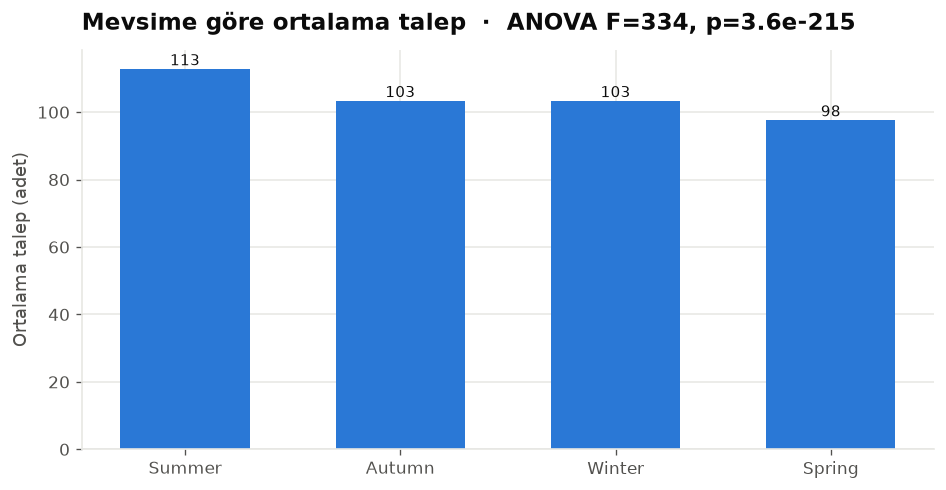

In [17]:
groups = [g["Demand"].values for _, g in df.groupby("Seasonality")]
f, p = stats.f_oneway(*groups)
print(f"ANOVA (mevsim): F={f:.2f}, p={p:.2e}")
means = df.groupby("Seasonality")["Demand"].mean().sort_values(ascending=False)
print("Sonuç:", "H0 RED — mevsimler farklı ✅" if p < 0.05 else "fark anlamsız")

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(means.index, means.values, color=BLUE, width=0.6)
for b, m in zip(bars, means.values):
    ax.text(b.get_x()+b.get_width()/2, m, f"{m:.0f}", ha="center", va="bottom", fontsize=9)
ax.set_title(f"Mevsime göre ortalama talep  ·  ANOVA F={f:.0f}, p={p:.1e}")
ax.set_ylabel("Ortalama talep (adet)"); ax.set_xlabel(""); plt.tight_layout(); plt.show()

> **Yorum.** Küçük p → en az bir mevsim diğerlerinden **anlamlı** farklı
> (mevsimsellik doğrulanır).
>
> **İş anlamı.** Sezonluk stok planı şart; sabit politika stok-out / fazla stok
> riskini artırır.

### 4.3 · Kategoriler arası fark — ANOVA

In [18]:
groups = [g["Demand"].values for _, g in df.groupby("Category")]
f, p = stats.f_oneway(*groups)
print(f"ANOVA (kategori): F={f:.2f}, p={p:.2e}")
print("Sonuç:", "H0 RED — kategoriler farklı ✅" if p < 0.05 else "fark anlamsız")

ANOVA (kategori): F=3187.56, p=0.00e+00
Sonuç: H0 RED — kategoriler farklı ✅


> **Yorum.** Anlamlı p → kategoriler arası talep farkı şansa bağlı değil.
>
> **İş anlamı.** Kategori bazlı tedarik/raf stratejisi; A-sınıfı kategorilere öncelik
> (bkz. ABC analizi).

### 4.4 · Mağazalar arası fark — ANOVA

In [19]:
groups = [g["Demand"].values for _, g in df.groupby("Store ID")]
f, p = stats.f_oneway(*groups)
print(f"ANOVA (mağaza): F={f:.2f}, p={p:.2e}")
print("Sonuç:", "H0 RED — mağazalar farklı ✅" if p < 0.05 else "mağazalar benzer")

ANOVA (mağaza): F=57.58, p=1.34e-48
Sonuç: H0 RED — mağazalar farklı ✅


> **Yorum.** p-değeri mağazalar arası farkın anlamlılığını gösterir.
>
> **İş anlamı.** Fark anlamlıysa mağazaya özel allocation; değilse merkezi politika —
> operasyonel maliyeti etkiler.

### 4.5 · Fiyat – Talep korelasyonu — Pearson & Spearman

In [20]:
r_p, p_p = stats.pearsonr(df["Price"], df["Demand"])
r_s, p_s = stats.spearmanr(df["Price"], df["Demand"])
print(f"Pearson  : r={r_p:.3f}, p={p_p:.2e}")
print(f"Spearman : r={r_s:.3f}, p={p_s:.2e}")
print("Sonuç:", "H0 RED — anlamlı korelasyon ✅" if p_p < 0.05 else "anlamlı korelasyon yok")

Pearson  : r=-0.023, p=9.90e-11
Spearman : r=-0.024, p=2.01e-11
Sonuç: H0 RED — anlamlı korelasyon ✅


> **Yorum.** Negatif ve p<0.05 katsayı → fiyat arttıkça talep anlamlı **düşüyor**
> (esneklik). Pearson doğrusal, Spearman monotonik ilişkiyi ölçer; uyum sağlamlığı
> destekler.
>
> **İş anlamı.** Fiyat, talebi yönetmenin doğrudan kaldıracı; fiyat/indirim
> optimizasyonu satış ve stok devrini artırabilir.

### 4.6 · Talebin normalliği — Shapiro–Wilk

In [21]:
samp = df["Demand"].sample(5000, random_state=42)  # Shapiro büyük n'de duyarlı
w, p = stats.shapiro(samp)
print(f"Shapiro-Wilk: W={w:.4f}, p={p:.2e}")
print("Sonuç:", "H0 RED — talep normal DEĞİL ✅" if p < 0.05 else "normallik reddedilemez")

Shapiro-Wilk: W=0.9832, p=6.33e-24
Sonuç: H0 RED — talep normal DEĞİL ✅


> **Yorum.** Küçük p → talep **normal değil** (QQ plot ile tutarlı).
>
> **İş anlamı.** Saf normal varsayım yanıltıcı olabilir; **quantile tahmin** (P90) gibi
> yöntemler daha güvenilir.

## 5 · Modelleme (hızlı baseline)

Sızıntı yaratan sonuç sütunları (`Units Sold`, `Units Ordered`) ve kimlikler
çıkarılıp kategorikler one-hot kodlanarak hızlı bir gradyan-artırma modeli eğitilir.
Bu bir **baseline**'dır; ana pipeline (`train_model.py`) lag/rolling özellikler +
Optuna ile **R² ≈ 0.95**'e ulaşır.

RMSE=29.55   MAE=22.19   R2=0.605


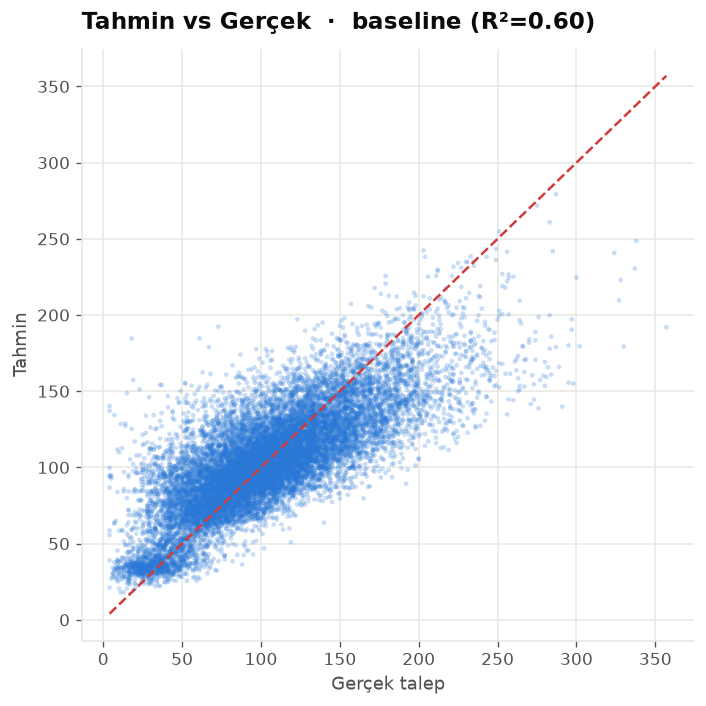

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

drop = ["Date", "Store ID", "Product ID", "Units Sold", "Units Ordered", "Demand"]
X, y = df.drop(columns=drop), df["Demand"]
cat = X.select_dtypes(exclude="number").columns.tolist()
num = [c for c in X.columns if c not in cat]
pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat),
                         ("num", "passthrough", num)])
model = Pipeline([("pre", pre), ("m", HistGradientBoostingRegressor(random_state=42))])

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(Xtr, ytr)
pred = model.predict(Xte)
rmse = np.sqrt(mean_squared_error(yte, pred)); r2 = r2_score(yte, pred)
print(f"RMSE={rmse:.2f}   MAE={mean_absolute_error(yte, pred):.2f}   R2={r2:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(yte, pred, s=8, alpha=0.25, color=BLUE, edgecolor="none")
lims = [min(yte.min(), pred.min()), max(yte.max(), pred.max())]
ax.plot(lims, lims, color=STATUS["critical"], linewidth=1.5, linestyle="--")
ax.set_title(f"Tahmin vs Gerçek  ·  baseline (R²={r2:.2f})")
ax.set_xlabel("Gerçek talep"); ax.set_ylabel("Tahmin"); plt.tight_layout(); plt.show()

> **Bulgu.** Baseline, **lag özellikleri olmadan** bile talebin önemli kısmını
> açıklıyor (R² ~0.6). Ana pipeline geçmiş-talep özellikleriyle ~0.95'e çıkar.
>
> **İş anlamı.** İşletme değişkenleri (fiyat, indirim, mevsim, kategori) tek başına
> güçlü sinyal; geçmiş talep eklenince tahmin operasyonel doğruluğa ulaşır.

## 6 · Sonuç

### Temel bulgular
| Alan | Bulgu | Test / Grafik |
|---|---|---|
| Veri kalitesi | Eksik/yinelenen/negatif değer yok | Temizlik |
| Promosyon | Talebi **anlamlı artırıyor** | t-testi & Mann–Whitney (p<0.05) |
| Mevsim / Kategori / Mağaza | Talep farkı **anlamlı** | ANOVA (p<0.05) |
| Fiyat–Talep | **Anlamlı negatif** ilişki | Pearson & Spearman |
| Dağılım | Talep **normal değil** | Shapiro & QQ plot |
| Zaman yapısı | **Haftalık mevsimsellik + otokorelasyon** | Decompose, ACF/PACF |

### İş anlamı
Talep; **fiyat/promosyon** ile yönlendirilebilir, **mevsim/kategori/mağaza** ile
segmentlenebilir, **geçmiş talep** ile yüksek doğrulukla tahmin edilebilir. Bu
bulgular segment bazlı güvenlik stoğu, sezonluk planlama ve fiyat-odaklı talep
yönetimi stratejilerini destekler.

### Sonraki adımlar
Çok-günlük tahmin ve senaryo analizi · promosyon takvimini modele açık değişken
olarak eklemek · fiyat esnekliği ile fiyat optimizasyonu.

---
*Talep & Stok Analizi · pandas · seaborn · scipy · statsmodels · scikit-learn*